In [1]:
import xarray as xr
import json

In [2]:
# Factual
# load true test data
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v1_dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)
    
### Load temperature data ###
ds_test_eth_fact = xr.open_dataset(settings['dataset_trefht_eth_transient'])
ds_test_eth_fact

# load DPA ensemble
dpa_eth_fact = xr.open_dataset("/work/fl53wumy-llaae_data_new_22092025/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/dpa_ensemble_after_100epochs/eth_ensemble_after_100_epochs/ETH_gen_dpa_ens_100_dataset_restored.nc")
dpa_eth_fact

<xarray.Dataset> Size: 6GB
Dimensions:          (ensemble_member: 100, time: 14307, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 6GB ...

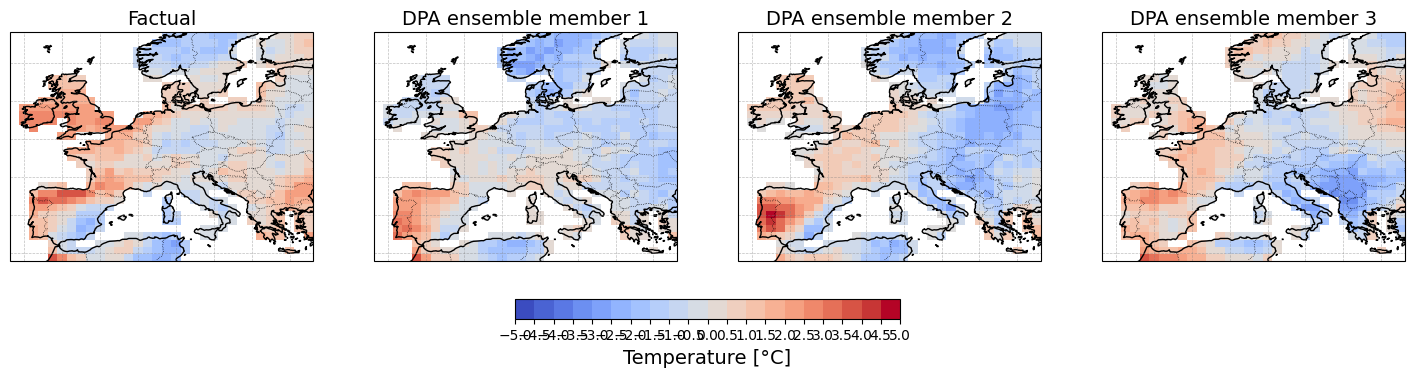

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Example dataset: ds.TREFHT should exist
date = 3000

# Fields for illustration
field_factual = ds_test_eth_fact.TREFHT.isel(time=date)
field_1 = dpa_eth_fact.TREFHT.isel(ensemble_member = 0, time=date)
field_2 = dpa_eth_fact.TREFHT.isel(ensemble_member = 1, time=date)
field_3 = dpa_eth_fact.TREFHT.isel(ensemble_member = 2, time=date)

# Plot parameters
vmin = -10
vmax = 10
levels = np.linspace(-5,5,21)
cmap = "coolwarm"

# Create figure and subplots
fig, axes = plt.subplots(
    1, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(18, 5)
)

titles = ["Factual", "DPA ensemble member 1", "DPA ensemble member 2", "DPA ensemble member 3"]
fields = [field_factual, field_1, field_2, field_3]

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=14)

# Add a shared colorbar
cbar = fig.colorbar(pc, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('Temperature [°C]', fontsize=14)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=10)

#plt.tight_layout()
plt.savefig("dpa_sample.pdf")
plt.show()


In [3]:
# Factual
# load true test data
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v1_dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)
    
### Load temperature data ###
ds_test_eth_cf = xr.open_dataset(settings['dataset_trefht_eth_nudged_shifted'])
ds_test_eth_cf

# load DPA ensemble
dpa_eth_cf = xr.open_dataset("/work/fl53wumy-llaae_data_new_22092025/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/dpa_ensemble_after_100epochs/eth_ensemble_after_100_epochs/ETH_cf_gen_dpa_ens_100_dataset_restored.nc")
dpa_eth_cf

<xarray.Dataset> Size: 6GB
Dimensions:          (ensemble_member: 100, time: 14307, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 6GB ...

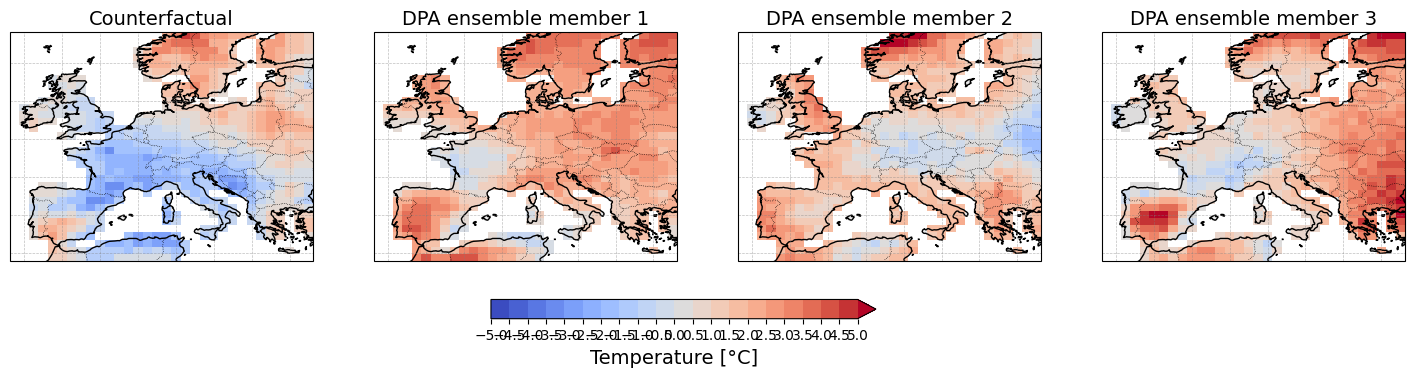

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Example dataset: ds.TREFHT should exist
date = 3050

# Fields for illustration
field_factual = ds_test_eth_cf.TREFHT.isel(time=date)
field_1 = dpa_eth_cf.TREFHT.isel(ensemble_member = 0, time=date)
field_2 = dpa_eth_cf.TREFHT.isel(ensemble_member = 1, time=date)
field_3 = dpa_eth_cf.TREFHT.isel(ensemble_member = 2, time=date)

# Plot parameters
vmin = -10
vmax = 10
levels = np.linspace(-5,5,21)
cmap = "coolwarm"

# Create figure and subplots
fig, axes = plt.subplots(
    1, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(18, 5)
)

titles = ["Counterfactual", "DPA ensemble member 1", "DPA ensemble member 2", "DPA ensemble member 3"]
fields = [field_factual, field_1, field_2, field_3]

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=14)

# Add a shared colorbar
cbar = fig.colorbar(pc, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('Temperature [°C]', fontsize=14)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=10)

#plt.tight_layout()
plt.savefig("cf_dpa_sample.pdf")
plt.show()


2040-07-22 00:00:00


Text(-0.125, 0.5, 'Counterfactual')

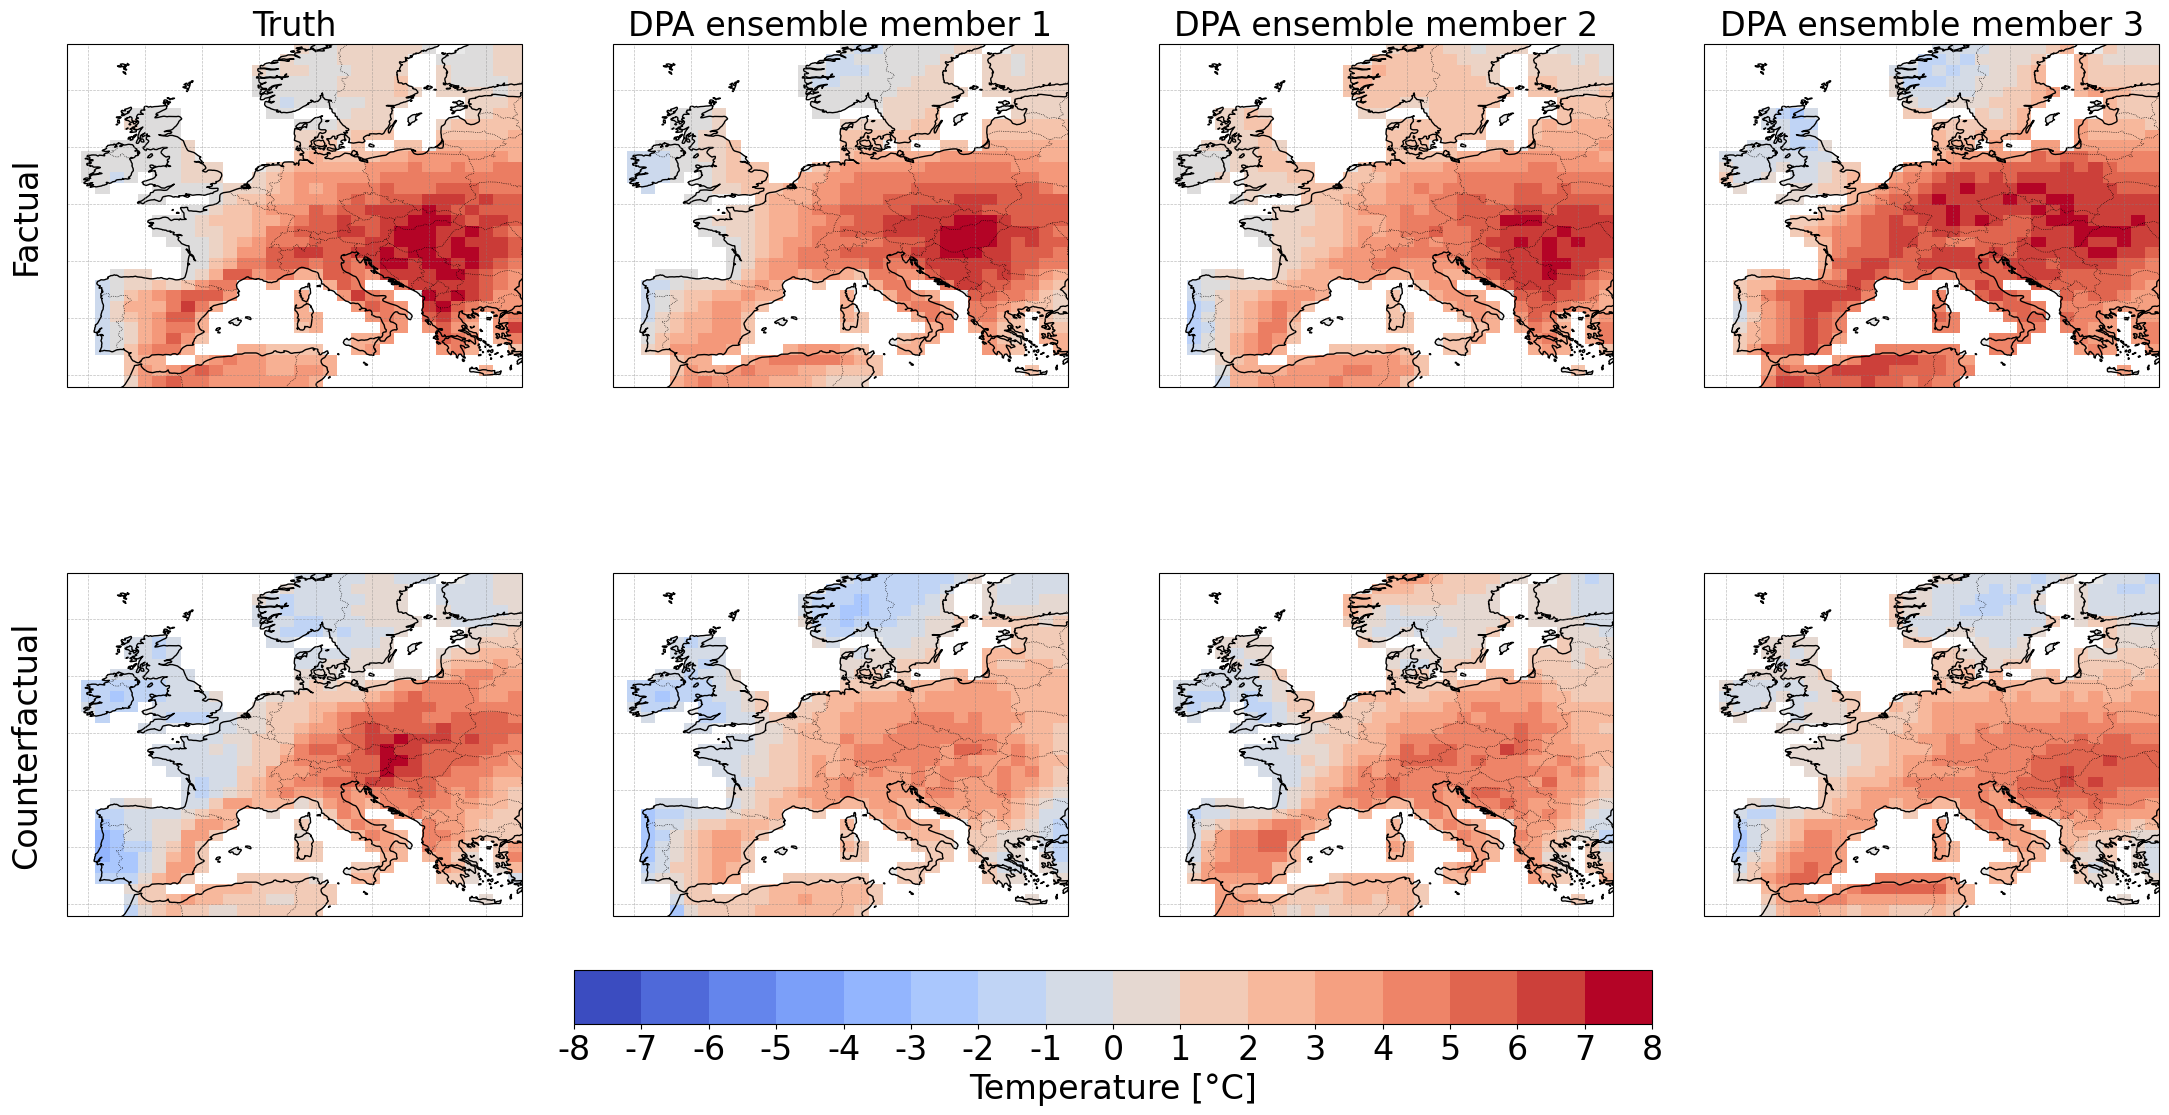

In [4]:
# both plots together

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Example dataset: ds.TREFHT should exist
date = 3620

# Factual Fields
field_factual = ds_test_eth_fact.TREFHT.isel(time=date)
print(field_factual.time.values)
field_1 = dpa_eth_fact.TREFHT.isel(ensemble_member = 0, time=date)
field_2 = dpa_eth_fact.TREFHT.isel(ensemble_member = 1, time=date)
field_3 = dpa_eth_fact.TREFHT.isel(ensemble_member = 2, time=date)

# Counterfactual Fields
field_cf = ds_test_eth_cf.TREFHT.isel(time=date)
field_1_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = 0, time=date)
field_2_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = 1, time=date)
field_3_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = 2, time=date)

# Plot parameters
vmin = -10
vmax = 10
levels = np.linspace(-8,8,17)
cmap = "coolwarm"

# Create figure and subplots
fig, axes = plt.subplots(
    2, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(27, 14)
)

titles = ["Truth", "DPA ensemble member 1", "DPA ensemble member 2", "DPA ensemble member 3", "", "", "", ""]
fields = [field_factual, field_1, field_2, field_3, field_cf, field_1_cf, field_2_cf, field_3_cf]
axes = axes.flatten()

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=24)

# Add a shared colorbar
cbar = fig.colorbar(pc, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05)
cbar.set_label('Temperature [°C]', fontsize=24)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=10)

#plt.tight_layout()
#plt.show()


# colorbar
# Label and tick styling
#cbar.set_label('Temperature [°C]', fontsize=14)

# Set tick positions
cbar.set_ticks(np.linspace(-8,8,17))

# Option 1: Automatically formatted numeric tick labels
cbar.set_ticklabels(range(-8,9,1), fontsize = 24)  # 1 decimal precision

# annotate
#axes[0].text(0.05, 0.95, "Factual", transform=axes[0].transAxes, 
#                fontsize=16, verticalalignment='top', 
#bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

axes[0].text(-0.125, 0.5, f'Factual', transform=axes[0].transAxes,
              fontsize=24, rotation=90, verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[4].text(-0.125, 0.5, f'Counterfactual', transform=axes[4].transAxes,
              fontsize=24, rotation=90, verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Font size and spacing
#cbar.ax.tick_params(labelsize=10)
#plt.savefig("dpa_field_samples.pdf")


In [18]:
fact_dpa_mean = dpa_eth_fact.TREFHT.mean(dim="ensemble_member")
fact_dpa_mean

cf_dpa_mean = dpa_eth_cf.TREFHT.mean(dim="ensemble_member")

Date: 2040-07-22 00:00:00


Text(-0.125, 0.5, 'Counterfactual')

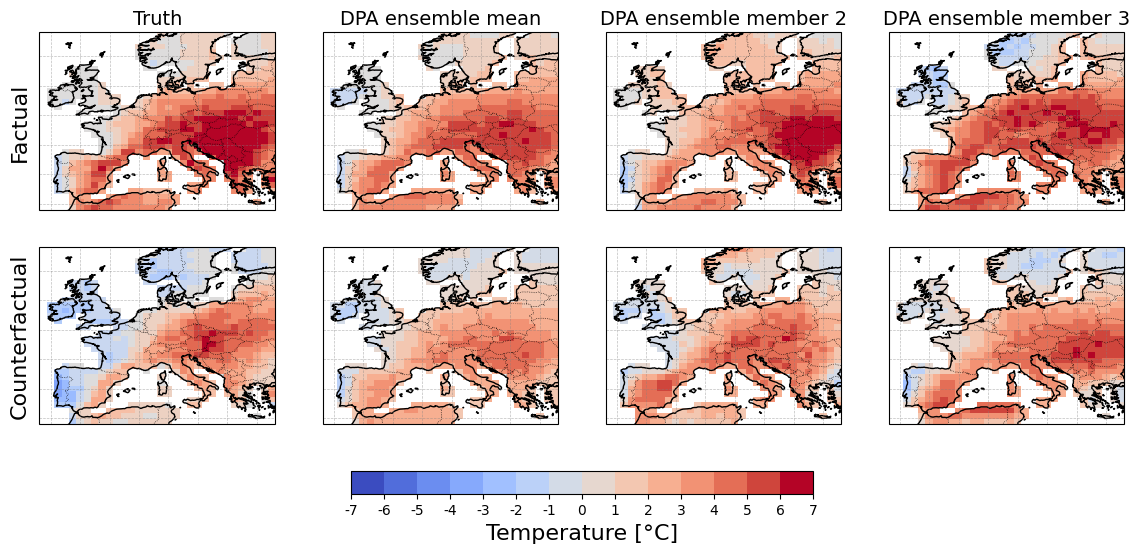

In [90]:
# both plots together including means

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Example dataset: ds.TREFHT should exist
date = 3620 #3600 looks good
print("Date:", ds_test_eth_fact.TREFHT.isel(time=date).time.values)

# Factual Fields
field_factual = ds_test_eth_fact.TREFHT.isel(time=date)
field_1 = fact_dpa_mean.isel(time=date)
field_2 = dpa_eth_fact.TREFHT.isel(ensemble_member = 1, time=date)
field_3 = dpa_eth_fact.TREFHT.isel(ensemble_member = 2, time=date)

# Counterfactual Fields
field_cf = ds_test_eth_cf.TREFHT.isel(time=date)
field_1_cf = cf_dpa_mean.isel(time=date)
field_2_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = 1, time=date)
field_3_cf = dpa_eth_cf.TREFHT.isel(ensemble_member = 2, time=date)

# Plot parameters
vmin = -10
vmax = 10
levels = np.linspace(-7,7,15)
cmap = "coolwarm"

# Create figure and subplots
fig, axes = plt.subplots(
    2, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(14, 6)
)

titles = ["Truth", "DPA ensemble mean", "DPA ensemble member 2", "DPA ensemble member 3", "", "", "", ""]
fields = [field_factual, field_1, field_2, field_3, field_cf, field_1_cf, field_2_cf, field_3_cf]
axes = axes.flatten()

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=14)

# Add a shared colorbar
cbar = fig.colorbar(pc, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('Temperature [°C]', fontsize=16)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=10)

#plt.tight_layout()
#plt.show()


# colorbar
# Label and tick styling
#cbar.set_label('Temperature [°C]', fontsize=14)

# Set tick positions
cbar.set_ticks(np.linspace(-7,7,15))

# Option 1: Automatically formatted numeric tick labels
cbar.set_ticklabels(range(-7,8,1))  # 1 decimal precision

# annotate
#axes[0].text(0.05, 0.95, "Factual", transform=axes[0].transAxes, 
#                fontsize=16, verticalalignment='top', 
#bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

axes[0].text(-0.125, 0.5, f'Factual', transform=axes[0].transAxes,
              fontsize=16, rotation=90, verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[4].text(-0.125, 0.5, f'Counterfactual', transform=axes[4].transAxes,
              fontsize=16, rotation=90, verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Font size and spacing
#cbar.ax.tick_params(labelsize=10)
#plt.savefig("dpa_sample.pdf")


(4769,)
dpa_ens_ger_1300: (4769, 100)
dpa_ens_mean_ger: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-6.5934012 , -4.76238872, -2.86940822, ...,  7.86786842,
        3.12546796,  7.49126921], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
lower env: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-4.61054556, -2.73984964, -1.14743082, ..., 10.26219181,
        4.88908004,  9.98653076], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
upper env: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-8.57625684, -6.7849278 , -4.59138562, ...,  5.47354503,
        1.36185587,  4.99600766], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00


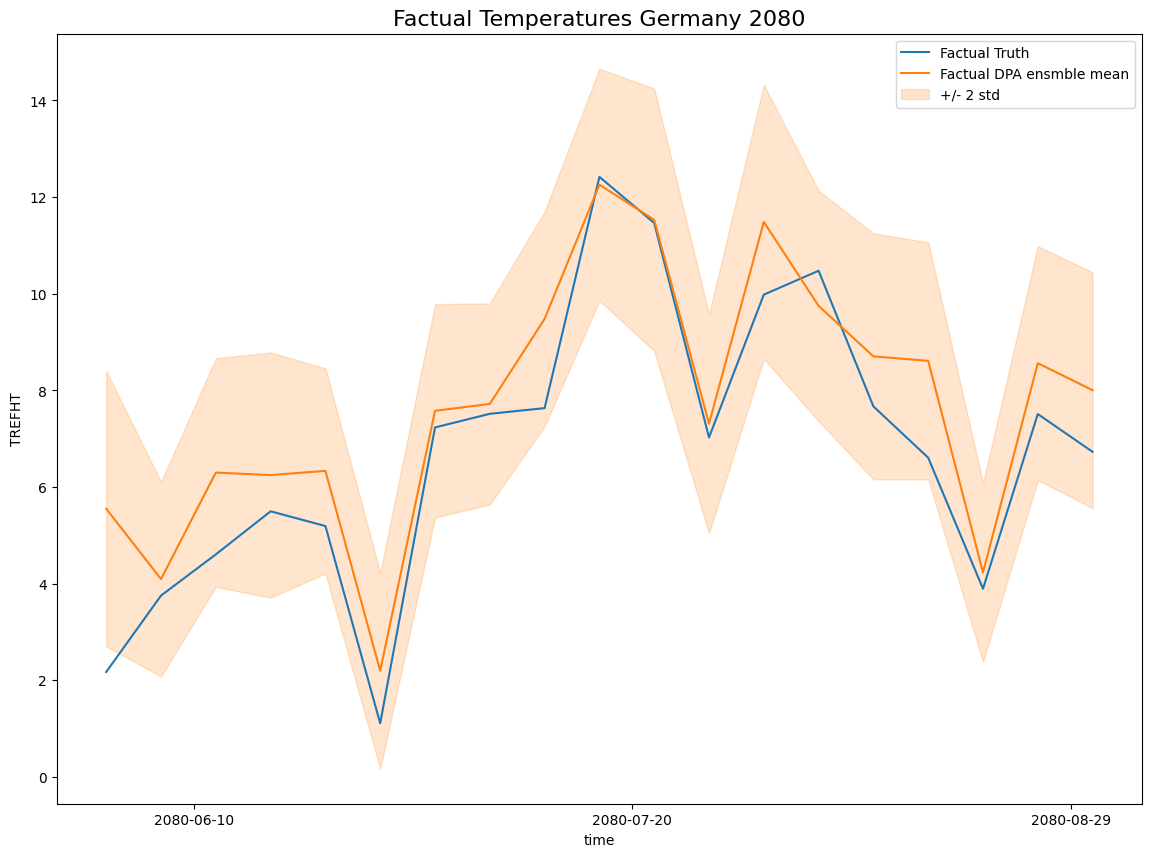

In [40]:
###################
### Time Series ###
###################
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import dpa_ensemble as de
import utils as ut
import evaluation

# Germany
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

year = "2080"

### Factual ###
fig, ax = evaluation.plot_dpa_time_series(true_t = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens = dpa_eth_fact.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens_mean = fact_dpa_mean.isel(time=slice(0,4769)),  
                                          lat_min = ger_lat_min, 
                                          lat_max = ger_lat_max, 
                                          lon_min = ger_lon_min, 
                                          lon_max = ger_lon_max, 
                                          plot_year = year,
                                          figsize_ts = (14,10),
                                          title_fontsize = 16,
                                          title = f"Factual Temperatures Germany {year}", 
                                          climate = "Factual"
                                          )        
#fig.savefig(f"{save_path_eth}/Germany/Germany_mean_fact_T_ts_{year}.png")
plt.show()



(4769,)
dpa_ens_ger_1300: (4769, 100)
dpa_ens_mean_ger: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-5.38673133, -3.18754684, -1.27072825, ...,  1.47544353,
       -1.10737989,  0.47607154], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
lower env: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-3.68724056, -1.42868027,  0.61226126, ...,  3.43023783,
        0.61251061,  2.63794055], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
upper env: <xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([-7.08622209, -4.94641341, -3.15371776, ..., -0.47935076,
       -2.82727039, -1.68579746], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00


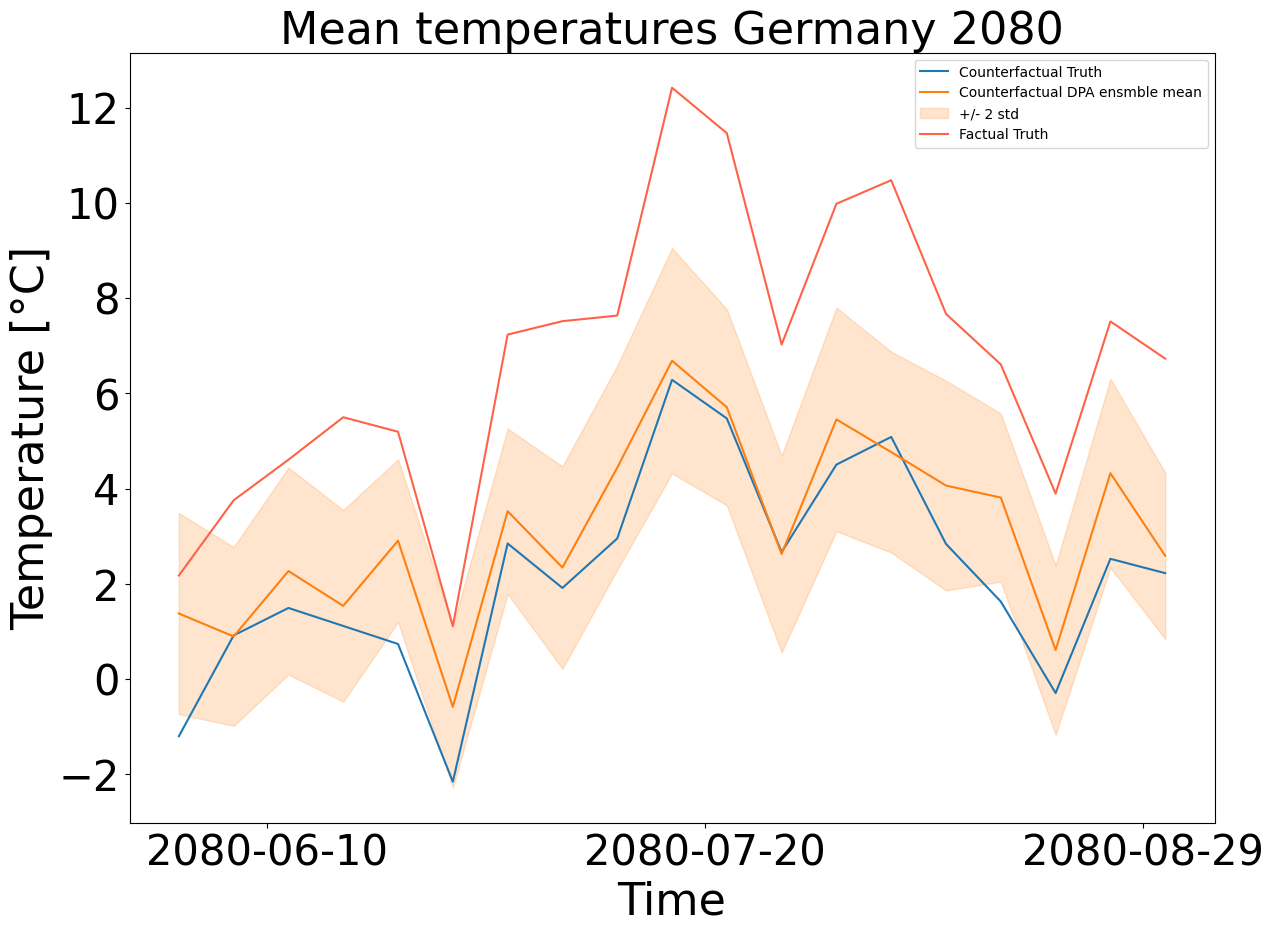

In [52]:
### Factual ###
fig, ax = evaluation.plot_dpa_time_series(true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens = dpa_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens_mean = cf_dpa_mean.isel(time=slice(0,4769)),  
                                          lat_min = ger_lat_min, 
                                          lat_max = ger_lat_max, 
                                          lon_min = ger_lon_min, 
                                          lon_max = ger_lon_max, 
                                          plot_year = year,
                                          figsize_ts = (14,10),
                                          title_fontsize = 16,
                                          title = f"Factual Temperatures Germany {year}", 
                                          climate = "Counterfactual"
                                          )        
#fig.savefig(f"{save_path_eth}/Germany/Germany_mean_fact_T_ts_{year}.png")

### add factual time series ###
temp_true_ger_pre = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))

# create weights
# 1) define weights as above
weights_ger = np.cos(np.deg2rad(temp_true_ger_pre['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_ger = xr.DataArray(weights_ger, coords={'lat': temp_true_ger_pre['lat']}, dims=['lat'])

temp_true_ger = temp_true_ger_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))
temp_true_ger.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).plot(ax=ax, label=f"Factual Truth", color = "tomato")



#dpa_ens_std = dpa_ens.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).std(dim="ensemble_member") # before: dpa_ensemble_restored.TREFHT
#dpa_ens_std_ger = dpa_ens_std.weighted(w_da_ger).mean(dim=('lat', 'lon'))
ax.set_ylabel("Temperature [°C]", fontsize = 32)
ax.set_xlabel("Time", fontsize = 32)
plt.tick_params(axis='both', which='major', labelsize=30)

# title
plt.title("Mean temperatures Germany 2080", fontsize=32)
plt.legend()
plt.savefig("example_dpa_time_series.pdf")
plt.show()

torch.Size([4769, 32, 32])
torch.Size([4769, 32, 32])
torch.Size([32, 32])
input array is torch tensor
data_np dimensions: 2


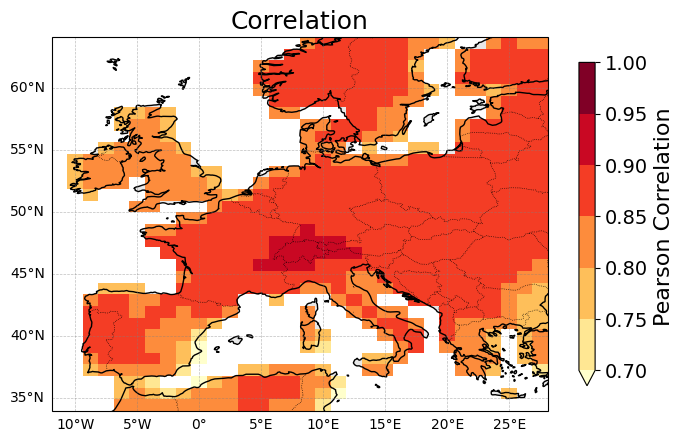

In [79]:
# CORRELATION
import torch

def plot_map(field, levels, cmap="bwr", cmap_label = ""):
    
    # create plot with a map projection
    fig, ax = plt.subplots(
        subplot_kw={'projection': ccrs.PlateCarree()}, 
        figsize=(14, 10)
    )
    
    # plot the data
    field.plot(ax=ax,
               transform=ccrs.PlateCarree(),
               cmap=cmap,
               levels=levels,
               cbar_kwargs={'label': cmap_label, 'shrink': 0.7})
    
    # add coastlines and continents
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    
    # optional: gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    #plt.show()

    return fig, ax

### Counterfactual ###
######################

## turn dpa ens (mean) into torch array
dpa_ens_mean_cf_1300_raw_pt = torch.from_numpy(cf_dpa_mean.isel(time=slice(0,4769)).values) #dpa_ens_mean_pt

## turn truth array into torch array 
eth_cf_1300_test = torch.from_numpy(ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)).values).permute(2, 0, 1) #dpa_ens_mean_pt

print(dpa_ens_mean_cf_1300_raw_pt.shape)
print(eth_cf_1300_test.shape)

# calculate correlation
r_cols_cf = evaluation.pearsonr_cols(eth_cf_1300_test, dpa_ens_mean_cf_1300_raw_pt, dim=0)  # shape: (648,)
print(r_cols_cf.shape)

corr_spatial_cf = ut.torch_to_dataarray(r_cols_cf, ds_test_eth_cf, name="Pearson correlation coefficient")

# plot
fig, ax = ut.plot_map(corr_spatial_cf, np.linspace(0.7, 1, 7), cmap="YlOrRd", cmap_label = "Pearson Correlation")
ax.set_title("Correlation", fontsize=18)

# Access the colorbar from the plotted DataArray (if plot_map uses xarray or plt)
cbar = ax.collections[0].colorbar  # works for xarray DataArray.plot()

# Change the colorbar label font size
cbar.set_label('Pearson Correlation', fontsize=16)

# Optionally, adjust tick label size
cbar.ax.tick_params(labelsize=14)

plt.savefig(f"cf_correlation_eth_test_figure.pdf")
plt.show()
